In [ ]:
!pip install pandas spaCy 

In [ ]:
!python -m spacy download en_core_web_sm

In [2]:
import pandas as pd
import spacy

In [6]:
#When you execute nlp = spacy.load('en'), spaCy downloads and loads the pre-trained English language model
#into memory and assigns it to the variable nlp.
#This pre-trained model contains information about word vectors, part-of-speech tags, syntactic dependencies, and other linguistic features necessary for various NLP tasks.

nlp = spacy.load("en_core_web_sm")

In [7]:
text = "A customer in New York City wants to give a review."

#Process the text using spaCy
doc = nlp(text)

In [10]:
#Tokenization, Part Of Speech tagging, and dependency parsing
for token in doc:
    print(f"Token: {token.text}, POS: {token.pos_}, Dependency: {token.dep_}")

Token: A, POS: DET, Dependency: det
Token: customer, POS: NOUN, Dependency: nsubj
Token: in, POS: ADP, Dependency: prep
Token: New, POS: PROPN, Dependency: compound
Token: York, POS: PROPN, Dependency: compound
Token: City, POS: PROPN, Dependency: pobj
Token: wants, POS: VERB, Dependency: ROOT
Token: to, POS: PART, Dependency: aux
Token: give, POS: VERB, Dependency: xcomp
Token: a, POS: DET, Dependency: det
Token: review, POS: NOUN, Dependency: dobj
Token: ., POS: PUNCT, Dependency: punct


In [12]:
#Filtering stop words and punctuation
filtered_tokens = [token for token in doc if not token.is_stop]
print("\nFiltered Tokens:")
for token in filtered_tokens:
    print(f"Token: {token.text}, POS: {token.pos_}, Dependency: {token.dep_}")


Filtered Tokens:
Token: customer, POS: NOUN, Dependency: nsubj
Token: New, POS: PROPN, Dependency: compound
Token: York, POS: PROPN, Dependency: compound
Token: City, POS: PROPN, Dependency: pobj
Token: wants, POS: VERB, Dependency: ROOT
Token: review, POS: NOUN, Dependency: dobj
Token: ., POS: PUNCT, Dependency: punct


In [13]:
#Named Entity Recognition (NER)
for ent in doc.ents:
    print(f"Entity: {ent.text}, Label: {ent.label_}")

Entity: New York City, Label: GPE


In [ ]:
#Lemmatization - reducing words to their base or dictionary form
# running -> run
# better -> good
# cars -> car
# studies -> study

print("\nLemmatization:")
for token in doc:
    print(f"Token: {token.text}, Lemma: {token.lemma_}")


Lemmatization:
Token: A, Lemma: a
Token: customer, Lemma: customer
Token: in, Lemma: in
Token: New, Lemma: New
Token: York, Lemma: York
Token: City, Lemma: City
Token: wants, Lemma: want
Token: to, Lemma: to
Token: give, Lemma: give
Token: a, Lemma: a
Token: review, Lemma: review
Token: ., Lemma: .


In [17]:
#Proper Pipeline
processed_tokens = []

for token in doc:
    # Remove stop words and punctuation
    if token.is_stop or token.is_punct:
        continue
    # Lemmatization and lowercasing
    lemma = token.lemma_.lower()
    processed_tokens.append(lemma)

print("\nCleaned Text:")
print(" ".join(processed_tokens))


Cleaned Text:
customer new york city want review


In [ ]:
!pip install wordcloud

In [20]:
from wordcloud import WordCloud

In [23]:
file_path = "./sentiment_examples.txt"
with open(file_path, 'r') as file:
    texts = file.readlines()

In [24]:
texts

['"I love the new features of your product! It has greatly improved my productivity."\n',
 '"The customer support was exceptional in New York. They resolved my issue promptly and professionally."\n',
 '"The quality of your service exceeded my expectations in Prague. I\'m impressed!"\n',
 '"I\'m extremely satisfied with my purchase. The product works flawlessly."\n',
 '"The user interface is intuitive and easy to navigate. Kudos to your design team!"\n',
 '"I had a positive experience shopping on your website. The checkout process was smooth."\n',
 '"Your company values customer feedback, and it shows in the improvements you\'ve made."\n',
 '"The pricing is fair, and the value I get in return is fantastic."\n',
 '"I appreciate the personalized recommendations. It makes shopping more convenient."\n',
 '"The delivery was prompt, and the packaging was secure. Everything arrived in perfect condition."']

In [37]:
token_lists = []
filtered_token_lists = []
pos_tag_lists = []
ner_lists = []

for text in texts:
    doc = nlp(text.strip())
    
    tokens = [token.text for token in doc]
    token_lists.append(tokens)
    
    filtered_tokens = [token.text for token in doc if not token.is_stop and not token.is_punct]
    filtered_token_lists.append(filtered_tokens)
    
    pos_tags = [(token.text, token.pos_) for token in doc]
    pos_tag_lists.append(pos_tags)
    
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    ner_lists.append(entities)

result_df = pd.DataFrame({
    'Text': texts,
    'Tokens': token_lists,
    'Filtered Tokens': filtered_token_lists,
    'POS Tags': pos_tag_lists,
    'Named Entities': ner_lists
})

In [38]:
result_df.head()

,Text,Tokens,Filtered Tokens,POS Tags,Named Entities
0,"""I love the new features of your product! It h...","["", I, love, the, new, features, of, your, pro...","[love, new, features, product, greatly, improv...","[("", PUNCT), (I, PRON), (love, VERB), (the, DE...",[]
1,"""The customer support was exceptional in New Y...","["", The, customer, support, was, exceptional, ...","[customer, support, exceptional, New, York, re...","[("", PUNCT), (The, DET), (customer, NOUN), (su...","[(New York, GPE)]"
2,"""The quality of your service exceeded my expec...","["", The, quality, of, your, service, exceeded,...","[quality, service, exceeded, expectations, Pra...","[("", PUNCT), (The, DET), (quality, NOUN), (of,...","[(Prague, GPE)]"
3,"""I'm extremely satisfied with my purchase. The...","["", I, 'm, extremely, satisfied, with, my, pur...","[extremely, satisfied, purchase, product, work...","[("", PUNCT), (I, PRON), ('m, AUX), (extremely,...",[]
4,"""The user interface is intuitive and easy to n...","["", The, user, interface, is, intuitive, and, ...","[user, interface, intuitive, easy, navigate, K...","[("", PUNCT), (The, DET), (user, NOUN), (interf...",[]


In [39]:
result_df.to_csv('processed_data.csv', index=False)

In [42]:
processed_df = pd.read_csv('processed_data.csv')
processed_df.head()

all_tokens = ' '.join(processed_df['Tokens'])

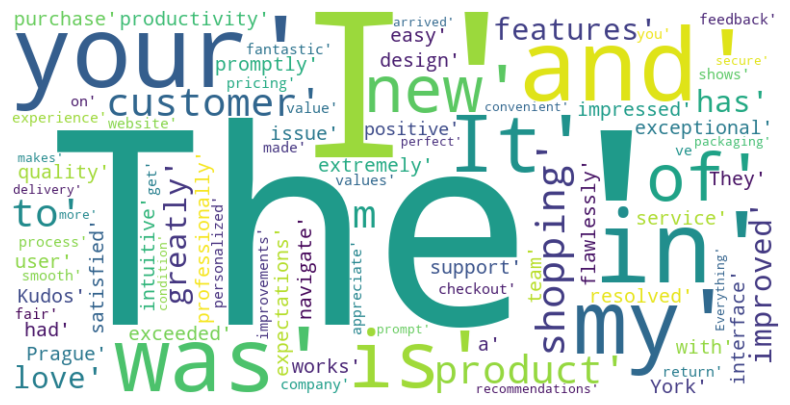

In [43]:
from matplotlib import pyplot as plt

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_tokens)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()
